# Random Forest - In-depth analysis

### Following the supervised benchmark in `Notebook_05`, Logistic Regression and Random Forest were retained for a more detailed analysis. This notebook focuses on Random Forest.

The objective here isn't to test a very large number of arbitrary configurations, but to investigate a limited set of hyperparameters that directly control the complexity and generalisation ability of the forest :

1. **Tree depth (`max_depth`)**
2. **Minimum number of samples per terminal leaf (`min_samples_leaf`)**
3. **Number of features considered at each split (`max_features`)**

The two prediction settings defined in the previous notebooks are preserved:

1. **Selected risk-factor features only**
2. **Selected features including screening tests** (`Hinselmann`, `Schiller`, `Citology`)

Model development is performed on the training data. 

The held-out test set remains untouched and will be used only once, after both Logistic Regression and Random Forest have been optimized, for the final comparison.

The primary model-selection metric remains PR-AUC / Average Precision, because the positive biopsy class is rare. ROC-AUC, recall, precision, F1-score, balanced accuracy and MCC are retained as complementary metrics.

### 1. Import libraries and selected training data

The feature subsets used here are the outputs of the previous feature-selection notebook. No additional feature selection is performed in this notebook.

Unlike Logistic Regression, Random Forest does not require feature scaling because tree splits depend on feature ordering rather than Euclidean distances or coefficient magnitudes.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV, cross_validate, cross_val_predict)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (make_scorer, precision_score, recall_score, f1_score, balanced_accuracy_score, matthews_corrcoef, ConfusionMatrixDisplay, confusion_matrix)

RANDOM_STATE = 28

SELECTED_DIR = Path("../01_DATA/selected")
PLOTS_DIR = Path("../04_FIGURES")
RESULTS_DIR = Path("../05_RESULTS")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

risk_train = pd.read_csv(SELECTED_DIR / "x_train_selected.csv")
diag_train = pd.read_csv(SELECTED_DIR / "diag_x_train_selected.csv")

y_risk = risk_train["Biopsy"]
X_risk = risk_train.drop(columns="Biopsy")

y_diag = diag_train["Biopsy"]
X_diag = diag_train.drop(columns="Biopsy")

assert y_risk.equals(y_diag)
y = y_risk

print("\n Risk-factor dataset :", X_risk.shape)
print(X_risk.columns.tolist())

print("\n Diagnostic-inclusive dataset :", X_diag.shape)
print(X_diag.columns.tolist())

print("\n Target distribution :")
print(y.value_counts())



 Risk-factor dataset : (584, 13)
['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs (number)', 'STDs:syphilis', 'STDs:HIV', 'Dx:CIN', 'Dx:HPV', 'Dx', 'smokes_missing', 'hormonal_contraceptives_missing', 'number_of_sexual_partners_missing', 'num_of_pregnancies_missing']

 Diagnostic-inclusive dataset : (584, 6)
['STDs:syphilis', 'Dx:CIN', 'Hinselmann', 'Schiller', 'Citology', 'hormonal_contraceptives_missing']

 Target distribution :
Biopsy
0    546
1     38
Name: count, dtype: int64


### 2. Evaluation strategy

As in the Logistic Regression analysis, hyperparameter tuning and performance estimation are separated using nested cross-validation :

- **Inner CV:** selects the Random Forest hyperparameters using PR-AUC.
- **Outer CV:** estimates the generalisation performance of the complete tuning procedure.

The outer loop uses repeated stratified 5-fold CV to obtain a more stable estimate despite the limited number of positive biopsies. The inner loop uses stratified 5-fold CV.

In [2]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

scoring = {"PR_AUC": "average_precision",
           "ROC_AUC": "roc_auc",
           "Recall": "recall",
           "Precision": make_scorer(precision_score, zero_division = 0), #to avoid having warnings output when the model predicts no positive
           "F1": "f1",
           "Balanced_accuracy": "balanced_accuracy",
           "MCC": make_scorer(matthews_corrcoef)}


### 3. Baseline Random Forest configuration

A Random Forest combines many decision trees trained on bootstrap samples. At each split, only a random subset of features is considered. The final prediction is obtained by aggregating the predictions of all trees.

Several parameters are deliberately kept fixed:

- `n_estimators = 500` : using many trees reduces Monte Carlo variability and generally stabilizes the forest. Once enough trees are used, increasing this value mainly increases computation time rather than model complexity.
- `bootstrap = True` : bootstrap resampling is a defining component of the classical Random Forest algorithm.
- `class_weight = "balanced"` : class weighting was selected in the previous imbalance analysis and is therefore kept fixed rather than re-optimized here.
- `criterion = "gini"` : the split criterion is kept fixed to avoid expanding the search space with a parameter that is secondary to the main bias–variance controls studied below.

The hyperparameter search instead focuses on the parameters that directly regulate tree complexity and feature randomization.

In [3]:
rf = RandomForestClassifier(n_estimators = 500, criterion = "gini", bootstrap = True, class_weight = "balanced", random_state = RANDOM_STATE)


### 4. Hyperparameters investigated

#### `max_depth`

`max_depth` limits how deep each tree can grow.

- shallow trees have higher bias but lower variance,
- very deep trees can model complex interactions but may overfit small training subsets

This parameter is particularly important here because the dataset is small and the number of positive biopsies is limited.

#### `min_samples_leaf`

`min_samples_leaf` controls the minimum number of training samples allowed in a terminal leaf.

A value of 1 allows very specific rules based on very few patients, whereas larger values force each terminal node to represent a broader subgroup. Increasing this parameter can therefore reduce overfitting and make the learned rules more robust.
`min_samples_split` is left at its default value because `min_samples_leaf` already provides a direct and interpretable control over the minimum size of terminal patient groups.

#### `max_features`

`max_features` controls how many candidate predictors are considered at each split.

- smaller values increase diversity between trees,
- larger values allow each tree to use more of the available information at each split but can make the trees more similar

Because the selected feature sets are relatively small, several realistic proportions are explored.

A randomized search is used instead of an exhaustive grid because many hyperparameter combinations are possible and the dataset doesn't justify an unnecessarily large computational search.

In [4]:
param_distributions = {"max_depth" : [None, 3, 5, 8, 12], "min_samples_leaf" : [1, 2, 4, 8, 12], "max_features" : ["sqrt", 0.5, 0.75, 1.0]}
N_ITER_SEARCH = 20

### 5. Nested cross-validation

`RandomizedSearchCV` selects the hyperparameter configuration maximizing Average Precision in the inner folds. Then, the complete search object is evaluated in the repeated outer cross-validation.

This provides a more realistic estimate of the performance expected from the full tuning procedure.

In [ ]:
def nested_rf_cv(X, y):
    search = RandomizedSearchCV(estimator = rf, param_distributions = param_distributions, n_iter = N_ITER_SEARCH, scoring = "average_precision", cv = inner_cv, refit = True, random_state = RANDOM_STATE)
    nested_scores = cross_validate(estimator=search, X=X, y=y, cv=outer_cv, scoring=scoring, return_estimator=True)
    return nested_scores

In [6]:
risk_nested = nested_rf_cv(X_risk, y)
diag_nested = nested_rf_cv(X_diag, y)

### 6. Cross-validated performance

The primary comparison is based on mean PR-AUC, while standard deviation is used to assess stability across outer folds.

In [7]:
def summarize_nested_scores(nested_scores):
    rows = []
    for metric in scoring:
        values = nested_scores[f"test_{metric}"]
        rows.append({"Metric": metric,
                     "Mean": values.mean(),
                     "Std": values.std(),
                     "Median": np.median(values),
                     "Min": values.min(),
                     "Max": values.max()})
    return pd.DataFrame(rows).set_index("Metric")

risk_summary = summarize_nested_scores(risk_nested)
diag_summary = summarize_nested_scores(diag_nested)

display(risk_summary.round(3))
display(diag_summary.round(3))

risk_summary.to_csv(RESULTS_DIR / "random_forest_nested_cv_risk.csv")
diag_summary.to_csv(RESULTS_DIR / "random_forest_nested_cv_diag.csv")

,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.119,0.034,0.122,0.055,0.180
ROC_AUC,0.605,0.098,0.616,0.331,0.758
Recall,0.331,0.183,0.286,0.125,0.875
Precision,0.123,0.060,0.115,0.045,0.286
F1,0.161,0.059,0.160,0.080,0.273
Balanced_accuracy,0.556,0.062,0.556,0.394,0.677
MCC,0.084,0.083,0.080,-0.108,0.217


,Mean,Std,Median,Min,Max
Metric,,,,,
PR_AUC,0.685,0.167,0.662,0.454,0.975
ROC_AUC,0.943,0.054,0.938,0.783,0.999
Recall,0.869,0.112,0.875,0.714,1.000
Precision,0.627,0.118,0.615,0.412,1.000
F1,0.722,0.095,0.737,0.526,0.923
Balanced_accuracy,0.915,0.056,0.919,0.825,0.991
MCC,0.713,0.101,0.725,0.509,0.922


Random Forest achieved strong overall performance, with high recall (0.869), balanced accuracy (0.915) and MCC (0.713). The mean PR-AUC was 0.685, although its relatively large variability across outer folds highlights the uncertainty associated with the limited number of positive biopsy cases.

In [8]:
def compact_summary(risk_summary, diag_summary):
    metrics = ["PR_AUC", "MCC", "Recall", "Precision", "F1", "ROC_AUC"]
    table = pd.DataFrame(index=metrics)
    table["Selected risk factors"] = [
        f"{risk_summary.loc[m, 'Mean']:.3f} ± {risk_summary.loc[m, 'Std']:.3f}"
        for m in metrics]
    table["Selected + diagnostics"] = [
        f"{diag_summary.loc[m, 'Mean']:.3f} ± {diag_summary.loc[m, 'Std']:.3f}"
        for m in metrics]
    return table

rf_slide_table = compact_summary(risk_summary, diag_summary)
rf_slide_table

,Selected risk factors,Selected + diagnostics
PR_AUC,0.119 ± 0.034,0.685 ± 0.167
MCC,0.084 ± 0.083,0.713 ± 0.101
Recall,0.331 ± 0.183,0.869 ± 0.112
Precision,0.123 ± 0.060,0.627 ± 0.118
F1,0.161 ± 0.059,0.722 ± 0.095
ROC_AUC,0.605 ± 0.098,0.943 ± 0.054


### 7. Stability of hyperparameter selection

A single optimal Random Forest configuration may be misleading on a small dataset. The hyperparameters selected in each outer fold are therefore inspected.

In [24]:
def extract_best_params(nested_scores):
    return pd.DataFrame([est.best_params_
        for est in nested_scores["estimator"]])

risk_best_params = extract_best_params(risk_nested)
diag_best_params = extract_best_params(diag_nested)

print("Risk factors only:")
display(risk_best_params.value_counts(dropna=False).rename("Count").reset_index())
print(risk_best_params.shape)

print("\nSelected + diagnostics:")
display(diag_best_params.value_counts(dropna=False).rename("Count").reset_index())
print(diag_best_params.shape)

risk_best_params.to_csv(RESULTS_DIR / "random_forest_best_params_outer_folds_risk.csv", index = False)
diag_best_params.to_csv(RESULTS_DIR / "random_forest_best_params_outer_folds_diag.csv", index = False)

Risk factors only:


,min_samples_leaf,max_features,max_depth,Count
0,2,1.0,3.0,7
1,1,0.75,3.0,5
2,12,0.75,NaN,3
3,1,1.0,3.0,3
4,12,0.5,3.0,2
5,2,sqrt,3.0,2
6,12,1.0,3.0,2
7,1,sqrt,5.0,1


(25, 3)

Selected + diagnostics:


,min_samples_leaf,max_features,max_depth,Count
0,2,sqrt,3.0,12
1,4,0.5,8.0,6
2,2,0.5,12.0,2
3,12,0.5,3.0,2
4,4,0.75,5.0,1
5,1,sqrt,5.0,1
6,12,0.75,NaN,1


(25, 3)


Interpretation of parameters :
- `max_depth` = 3 : relatively simple trees, lower risk of overfitting,
- `min_samples_leaf` = 2 or 4 : a leaf can't be defined by a single patient,
- `max_features` = sqrt : at each split, only a small subset of variables is considered, increasing diversity among the trees

Hyperparameter selection was moderately stable across outer folds, with shallow trees and small leaves frequently preferred, suggesting that controlling tree complexity is important for limiting overfitting in this small dataset.

### 8. Final hyperparameter search on the complete training set

Nested CV is used above to estimate performance. A final randomized search is now fitted on the complete training set in order to freeze the Random Forest configuration that will later be evaluated on the held-out test set.

In [10]:
def fit_final_search(X, y):
    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring="average_precision",
        cv=inner_cv,
        refit=True,
        random_state=RANDOM_STATE,
        return_train_score=True)
    search.fit(X, y)
    return search

risk_search = fit_final_search(X_risk, y)
diag_search = fit_final_search(X_diag, y)

print("Risk factors only")
print("Best parameters:", risk_search.best_params_)
print("Best inner-CV PR-AUC:", round(risk_search.best_score_, 3))

print("\nSelected + diagnostics")
print("Best parameters:", diag_search.best_params_)
print("Best inner-CV PR-AUC:", round(diag_search.best_score_, 3))

Risk factors only
Best parameters: {'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3}
Best inner-CV PR-AUC: 0.13

Selected + diagnostics
Best parameters: {'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3}
Best inner-CV PR-AUC: 0.716


In [11]:
best_params_to_save = {"risk_factors": risk_search.best_params_, "selected_plus_diagnostics": diag_search.best_params_}

with open(RESULTS_DIR / "random_forest_best_hyperparameters.json", "w") as f:
    json.dump(best_params_to_save, f, indent=2)

### 9. Bias–variance behaviour of the searched configurations

The figure below compares mean training PR-AUC and mean validation PR-AUC for the best candidate configurations explored during the final search.

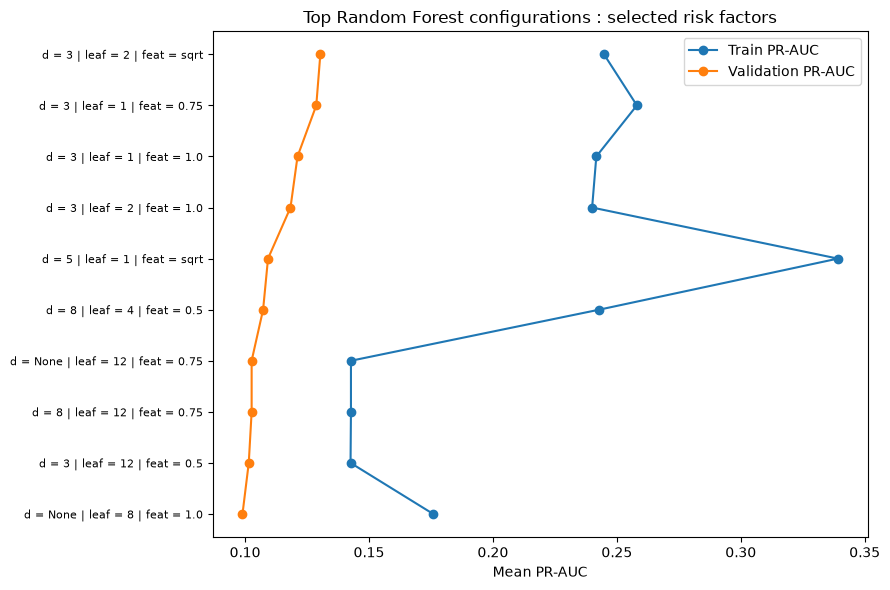

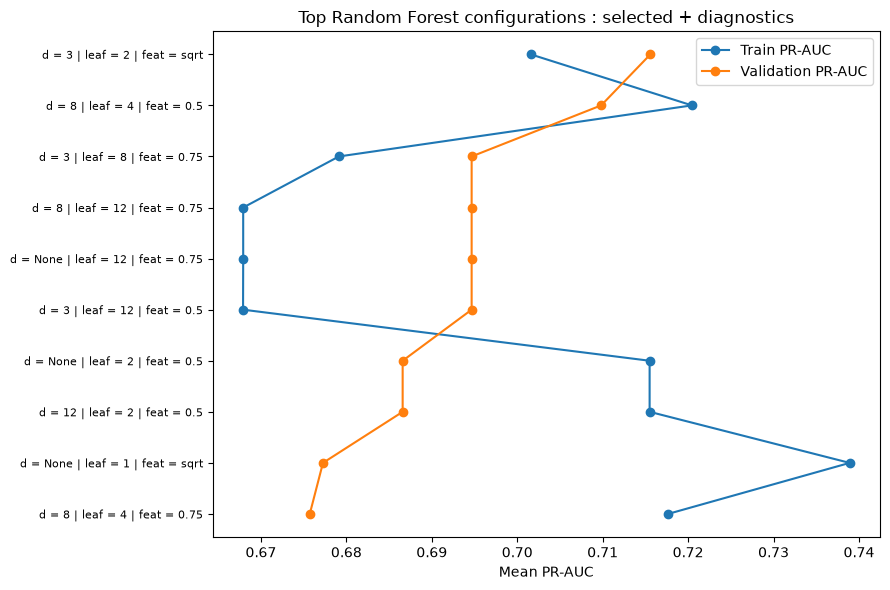

In [29]:
def plot_top_search_candidates(search, scenario_name, filename, n=10):
    results = pd.DataFrame(search.cv_results_)
    results = results.sort_values("rank_test_score").head(n).copy()
    results = results.sort_values("mean_test_score")
    labels = [f"d = {row['param_max_depth']} | leaf = {row['param_min_samples_leaf']} | feat = {row['param_max_features']}"
        for _, row in results.iterrows()]
    
    y_pos = np.arange(len(results))
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(results["mean_train_score"], y_pos, marker = "o", label = "Train PR-AUC")
    ax.plot(results["mean_test_score"], y_pos, marker = "o", label = "Validation PR-AUC")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Mean PR-AUC")
    ax.set_title(f"Top Random Forest configurations : {scenario_name}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches = "tight")
    plt.show()

plot_top_search_candidates(risk_search, "selected risk factors", "random_forest_top_configs_risk.png")
plot_top_search_candidates(diag_search, "selected + diagnostics", "random_forest_top_configs_diag.png")

The train validation comparison suggests that the best-performing Random Forest configurations are relatively regularized, while deeper or less constrained forests tend to show a larger generalization gap with increased overfitting.

The figure reinforces what was already observed in block 7 : relatively shallow trees and non-trivial leaves appear better suited to this small dataset.

### 10. Cross-validated permutation importance

Random Forest interpretation is less direct than Logistic Regression. Therefore, permutation importance is used instead of relying only on impurity-based feature importance. For each outer fold, the tuned model is fitted on the outer training subset and each feature is then permuted in the corresponding validation subset. This answers the question : ***which variables are really useful for the Random Forest to predict Biopsy ?***

This analysis is performed with a single stratified 5-fold outer loop to keep computation reasonable while preserving out-of-fold evaluation.

In [13]:
importance_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

def cross_validated_permutation_importance(X, y):
    rows = []
    for fold, (train_idx, valid_idx) in enumerate(importance_cv.split(X, y),start=1):

        X_train_fold = X.iloc[train_idx]
        X_valid_fold = X.iloc[valid_idx]
        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        search = RandomizedSearchCV(
            estimator = rf,
            param_distributions = param_distributions,
            n_iter = N_ITER_SEARCH,
            scoring = "average_precision",
            cv = inner_cv,
            refit = True,
            random_state = RANDOM_STATE)

        search.fit(X_train_fold, y_train_fold)

        importance = permutation_importance(
            search.best_estimator_,
            X_valid_fold,
            y_valid_fold,
            scoring = "average_precision",
            n_repeats = 20,
            random_state = RANDOM_STATE)

        for feature, mean_imp, std_imp in zip(X.columns, importance.importances_mean, importance.importances_std):
            rows.append({"Fold": fold, "Feature": feature, "Importance_mean": mean_imp, "Importance_std": std_imp})

    return pd.DataFrame(rows)

risk_importance = cross_validated_permutation_importance(X_risk, y)
diag_importance = cross_validated_permutation_importance(X_diag, y)

risk_importance.to_csv(RESULTS_DIR / "random_forest_permutation_importance_risk.csv", index = False)
diag_importance.to_csv(RESULTS_DIR / "random_forest_permutation_importance_diag.csv", index = False)

In [14]:
def summarize_importance(importance_df):
    return (importance_df.groupby("Feature")["Importance_mean"].agg(["mean", "std", "median"]).sort_values("mean", ascending = False))

risk_importance_summary = summarize_importance(risk_importance)
diag_importance_summary = summarize_importance(diag_importance)

display(risk_importance_summary.round(3))
display(diag_importance_summary.round(3))

,mean,std,median
Feature,,,
STDs (number),0.029,0.043,0.042
STDs:syphilis,0.005,0.006,0.004
num_of_pregnancies_missing,0.004,0.008,0.005
hormonal_contraceptives_missing,0.002,0.006,0.002
Hormonal Contraceptives,0.001,0.012,0.003
smokes_missing,0.001,0.002,0.000
Dx:CIN,0.000,0.000,0.000
number_of_sexual_partners_missing,0.000,0.000,0.000
IUD,-0.005,0.013,-0.007


,mean,std,median
Feature,,,
Schiller,0.460,0.156,0.495
Hinselmann,0.054,0.097,0.116
Citology,0.041,0.100,0.033
STDs:syphilis,0.030,0.068,0.000
hormonal_contraceptives_missing,0.013,0.015,0.012
Dx:CIN,-0.000,0.000,0.000


- Schiller = 0.460 ± 0.156: by far the most important variable. Shuffling it results in an average loss of approximately 0.46 in PR-AUC, indicating that the model relies heavily on this information
- Hinselmann = 0.054 ± 0.097: a much smaller and rather unstable contribution
- Cytology = 0.041 ± 0.100: same observation—low average importance and high variability
- STDs:syphilis = 0.030 ± 0.068: low contribution, here the median is also interesting : it's 0.000, meaning that in many folds, this variable contributes almost for nothing
- hormonal_contraceptives_missing = 0.013 ± 0.015: very low contribution
- Dx:CIN ≈ 0: the model shows virtually no loss in performance when this variable is shuffled

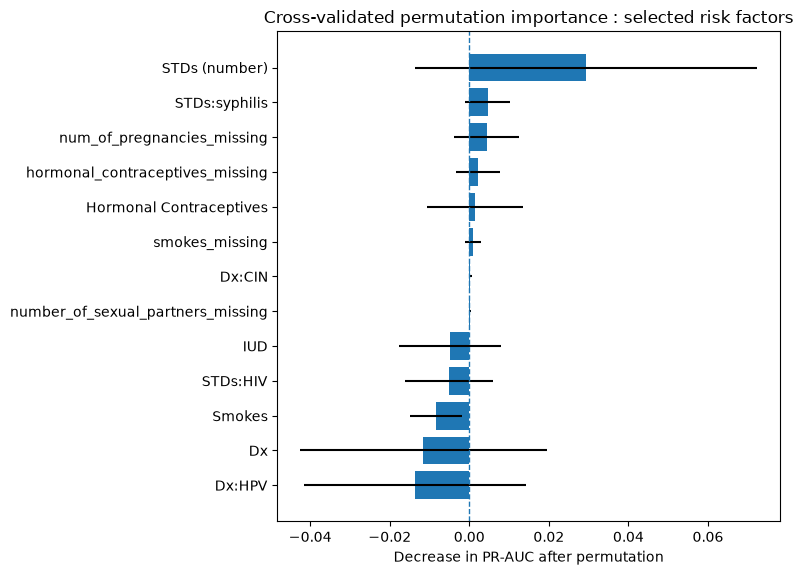

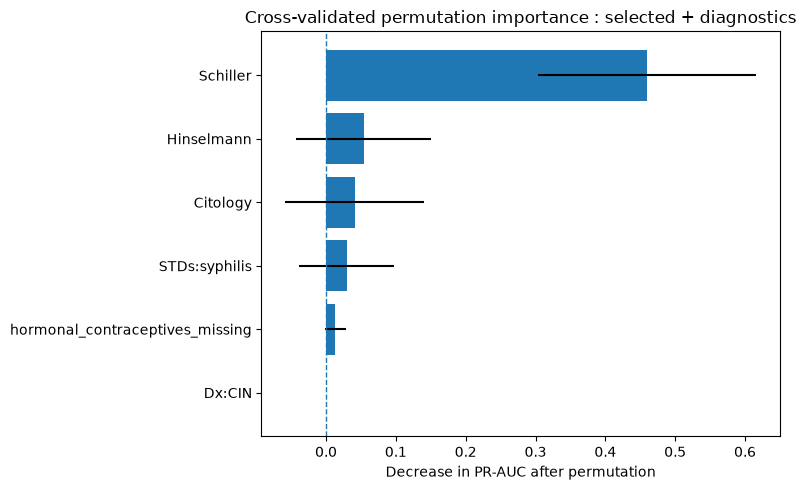

In [25]:
def plot_importance(importance_summary, scenario_name, filename):
    data = importance_summary.sort_values("mean")
    fig, ax = plt.subplots(figsize = (8, max(5, 0.45 * len(data))))
    ax.barh(data.index, data["mean"], xerr=data["std"])

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Decrease in PR-AUC after permutation")
    ax.set_title(f"Cross-validated permutation importance : {scenario_name}")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_importance(risk_importance_summary, "selected risk factors", "random_forest_permutation_importance_risk.png")
plot_importance(diag_importance_summary, "selected + diagnostics", "random_forest_permutation_importance_diag.png")

Permutation importance shows that Random Forest predictions are largely driven by the Schiller test, while the remaining predictors provide substantially smaller and less stable contributions across validation folds.

**NB :** Negative values can occur because of sampling variability (especially as the dataset is small) and shouldn't be interpreted as evidence that a variable is biologically protective.

### 11. Exploratory decision-threshold analysis

Although PR-AUC evaluates ranking performance over all thresholds, Random Forest probabilities must be converted into binary predictions.

The default threshold of 0.5 is not necessarily optimal in an imbalanced dataset, especially when class weighting is used. Therefore, an exploratory threshold analysis is performed using **out-of-fold predictions from the training data only**. In this approach, each patient is predicted by a model that did not see her during training. This serves much more realistic predictions for selecting the threshold.

The threshold maximizing MCC is identified as a statistical compromise between all four confusion-matrix components.

The selected threshold must be frozen before evaluating the final model on the held-out test set.

In [16]:
oof_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

def get_nested_oof_probabilities(X, y):
    search = RandomizedSearchCV(
        estimator = rf,
        param_distributions = param_distributions,
        n_iter = N_ITER_SEARCH,
        scoring = "average_precision",
        cv = inner_cv,
        refit = True,
        random_state = RANDOM_STATE)

    probabilities = cross_val_predict(
        search,
        X,
        y,
        cv = oof_cv,
        method = "predict_proba")[:, 1]

    return probabilities

risk_oof_prob = get_nested_oof_probabilities(X_risk, y)
diag_oof_prob = get_nested_oof_probabilities(X_diag, y)

In [26]:
def threshold_table(y_true, probabilities):
    rows = []
    for threshold in np.arange(0.05, 0.96, 0.01):
        pred = (probabilities >= threshold).astype(int)
        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, pred, zero_division = 0),
            "Recall": recall_score(y_true, pred),
            "F1": f1_score(y_true, pred),
            "Balanced_accuracy": balanced_accuracy_score(y_true, pred),
            "MCC": matthews_corrcoef(y_true, pred)})
    return pd.DataFrame(rows)

risk_thresholds = threshold_table(y, risk_oof_prob)
diag_thresholds = threshold_table(y, diag_oof_prob)

risk_best_threshold = risk_thresholds.loc[risk_thresholds["MCC"].idxmax()]
diag_best_threshold = diag_thresholds.loc[diag_thresholds["MCC"].idxmax()]

print("Risk factors : threshold maximizing MCC")
display(risk_best_threshold.round(3))

print("Selected + diagnostics : threshold maximizing MCC")
display(diag_best_threshold.round(3))

Risk factors : threshold maximizing MCC


Threshold            0.620
Precision            0.171
Recall               0.184
F1                   0.177
Balanced_accuracy    0.561
MCC                  0.118
Name: 57, dtype: float64

Selected + diagnostics : threshold maximizing MCC


Threshold            0.680
Precision            0.660
Recall               0.868
F1                   0.750
Balanced_accuracy    0.919
MCC                  0.738
Name: 63, dtype: float64

Threshold optimization identified 0.68 as the best statistical compromise according to MCC. At this threshold, the model maintained high sensitivity (0.868) while achieving a precision of 0.660 and an MCC of 0.738.

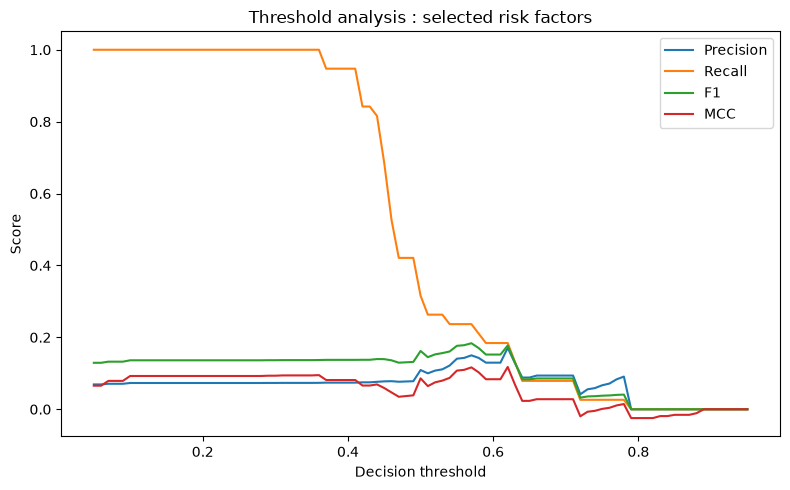

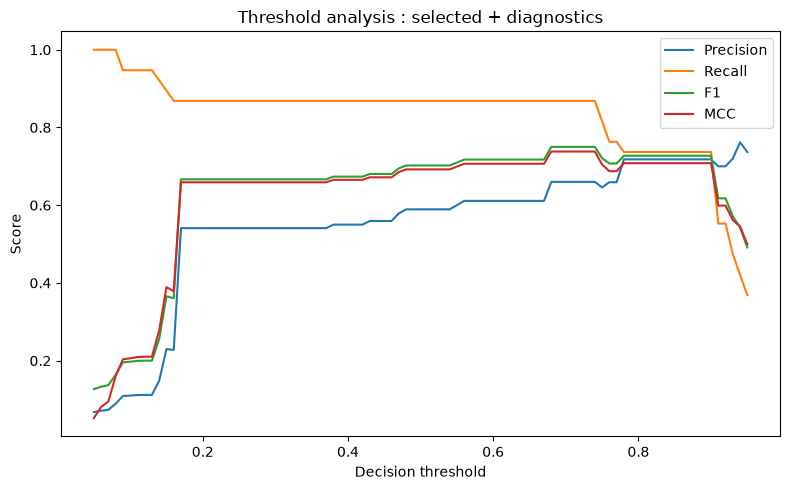

In [27]:
def plot_threshold_analysis(table, scenario_name, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for metric in ["Precision", "Recall", "F1", "MCC"]:
        ax.plot(table["Threshold"], table[metric], label = metric)

    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"Threshold analysis : {scenario_name}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_threshold_analysis(risk_thresholds, "selected risk factors", "random_forest_threshold_analysis_risk.png")
plot_threshold_analysis(diag_thresholds, "selected + diagnostics", "random_forest_threshold_analysis_diag.png")

### 12. Out-of-fold confusion matrices

The confusion matrices below are generated from out-of-fold training predictions using the threshold selected from the training data.

These out-of-fold predictions provide an internal estimate of classification behaviour, but the held-out test set is required for the final unbiased evaluation.

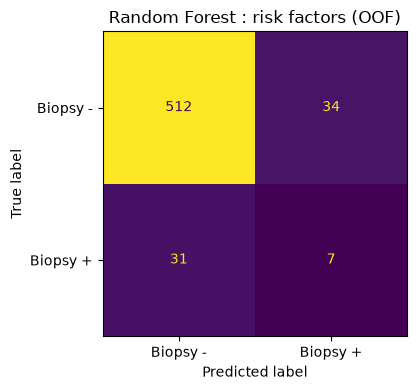

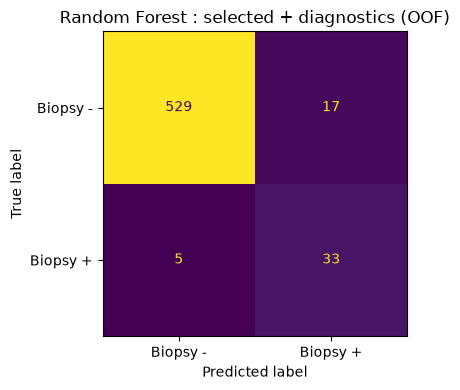

In [28]:
def plot_oof_confusion_matrix(y_true, probabilities, threshold, title, filename):
    pred = (probabilities >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)
    fig, ax = plt.subplots(figsize = (5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=["Biopsy -", "Biopsy +"])

    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_oof_confusion_matrix(y, risk_oof_prob, float(risk_best_threshold["Threshold"]), "Random Forest : risk factors (OOF)", "random_forest_confusion_matrix_oof_risk.png")
plot_oof_confusion_matrix(y, diag_oof_prob, float(diag_best_threshold["Threshold"]), "Random Forest : selected + diagnostics (OOF)", "random_forest_confusion_matrix_oof_diag.png")

The Random Forest correctly identified 33 of the 38 positive biopsies while producing only 17 false-positive predictions, resulting in high sensitivity with a relatively limited number of false predictions.

## Interpretation and conclusion

This notebook provided an in-depth evaluation of Random Forest, the nonlinear model retained alongside Logistic Regression after the supervised benchmark.

The analysis focused on a limited number of hyperparameters directly related to model complexity and overfitting : `max_depth`, `min_samples_leaf` and `max_features`. Class weighting was retained from the previous imbalance analysis, while the number of trees was fixed at a sufficiently large value to stabilize the ensemble.

A major difference was observed between the two prediction scenarios.

### Risk-factor-only scenario

When only selected upstream risk factors were used, **Random Forest showed limited predictive performance**. Nested cross-validation resulted in a mean PR-AUC of only 0.119 ± 0.034, with a recall of 0.331, precision of 0.123, F1-score of 0.161 and MCC of 0.084. Balanced accuracy was also close to chance level (0.556).

Hyperparameter selection frequently favoured relatively shallow trees, particularly `max_depth = 3`, suggesting that increasing model complexity didn't improve generalisation. The train–validation comparison further showed performance gaps for several more flexible configurations, indicating that additional tree complexity mainly increased overfitting rather than extracting useful predictive signal.

Permutation importance also revealed weak and unstable contributions from the selected risk factors. `STDs (number)` showed the largest positive importance, but its effect remained small and variable across folds, while most other variables had importances close to zero. Some variables even showed slightly negative permutation importance, which is more consistent with sampling variability and redundant information than with meaningful protective effects.

Decision-threshold adjustment did not compensate for this lack of predictive information. The out-of-fold confusion matrix showed that only **7 of the 38 positive biopsies were detected, while 31 were missed**. This confirms that the poor performance of the risk-factor-only model can't simply be corrected by changing the classification threshold.

Overall, the selected upstream risk factors appear insufficient for reliable biopsy prediction in this dataset, even when using a nonlinear ensemble model capable of modelling interactions.

### Diagnostic-inclusive scenario

The results radically changed when screening variables were included. In this setting, Random Forest achieved a mean nested-CV PR-AUC of 0.685 ± 0.167, with a recall of 0.869, precision of 0.627, F1-score of 0.722, balanced accuracy of 0.915 and MCC of 0.713.

Although PR-AUC varied across outer folds, the overall discrimination was substantially stronger than in the risk-factor-only scenario. Hyperparameter selection again tended to favour relatively constrained forests, supporting the importance of regularization in this small dataset.

Permutation importance showed that the model relied strongly on the **Schiller test**, with a mean decrease in PR-AUC of approximately 0.46. Hinselmann and Citology contributed less and showed greater variability, while the remaining selected variables had comparatively limited importance. This indicates that much of the predictive performance of the diagnostic-inclusive Random Forest is driven by information already contained in cervical screening tests.

Threshold optimization identified 0.68 as the threshold maximizing MCC on out-of-fold training predictions. At this threshold, precision was 0.660, recall 0.868, F1-score 0.750, balanced accuracy 0.919 and MCC 0.738. The corresponding confusion matrix showed that **33 of the 38 positive biopsies were correctly detected, with only 5 false negatives and 17 false positives**.

### Overall interpretation

The comparison between the two scenarios suggests that **the availability of diagnostic screening information has a much larger impact on prediction than increasing model complexity**. Random Forest was unable to recover strong predictive information from risk factors alone, whereas performance improved markedly once variables such as Schiller, Hinselmann and Citology were introduced.

This distinction is also important biologically. The risk-factor-only scenario addresses whether biopsy outcome can be predicted from upstream patient characteristics, whereas the diagnostic-inclusive scenario incorporates tests that are much closer to the biopsy outcome itself. The two scenarios therefore answer different prediction questions and should not be interpreted interchangeably.

Random Forest offers the advantage of modelling nonlinear relationships and interactions without requiring them to be specified in advance. However, in this dataset its additional flexibility does not overcome the limited information available in the risk-factor-only setting, and its interpretation is less direct than that of Logistic Regression.

The out-of-fold threshold and confusion-matrix results represent internal validation only. Hyperparameters and any retained classification threshold must be fixed before the held-out test set is used for the final evaluation.

### Next step - Notebook 08

The goal is now to compare the optimized Random Forest with the optimized Logistic Regression using their nested cross-validation performance, stability, model complexity and interpretability before performing the final unbiased evaluation on the untouched test set.